<a href="https://colab.research.google.com/github/ChikleNeha/deep_rl_course/blob/main/Unit1_lunar_lander.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 1. Install system dependencies for Box2D and Video Recording
!apt-get update && apt-get install -y swig python3-dev ffmpeg

# 2. Install the modern RL libraries
# We use 'gymnasium[box2d]' (the successor to gym) and SB3 v2.3+
!pip install "gymnasium[box2d]>=1.0.0"
!pip install "stable-baselines3[extra]>=2.3.2"
!pip install shimmy  # Required for compatibility between older envs and new SB3
!pip install huggingface_sb3  # To push your model to the Hub later

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,480 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,963 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,844 kB]
Hit:12 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Get:13 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64

In [3]:
import gymnasium as gym
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

# 1. Create the environment
# We use render_mode="rgb_array" so we can record videos later
env = gym.make("LunarLander-v3", render_mode="rgb_array")
env = Monitor(env) # Good practice for tracking statistics

# 2. Reset the environment (Note: Gymnasium returns two values now)
observation, info = env.reset()

print(f"✅ Environment initialized! Observation shape: {observation.shape}")

✅ Environment initialized! Observation shape: (8,)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyPacked has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type SwigPyObject has no __module__ attribute
<frozen importlib._bootstrap>:488: DeprecationWarning: builtin type swigvarlink has no __module__ attribute
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tz

In [4]:
# trying again
from stable_baselines3 import PPO

# 1. Re-initialize with "Expert" Hyperparameters for Python 3.12
# These are optimized to help the agent 'commit' to the landing
model = PPO(
    policy = "MlpPolicy",
    env = env,
    learning_rate = 0.0003, # Standard but effective
    n_steps = 2048,         # Larger buffer to see the whole flight
    batch_size = 64,        # Stable updates
    n_epochs = 10,          # More optimization per update
    gamma = 0.999,          # Focus on the very end of the episode (the landing)
    gae_lambda = 0.98,
    ent_coef = 0.01,        # Encourages exploration (prevents 'stopping midway')
    verbose = 1
)

# 2. Train for a solid 500k steps
# This is usually the 'magic number' for a perfect LunarLander
print("🚀 Starting the Master Training (500k steps)...")
model.learn(total_timesteps=500000, progress_bar=True)

# 3. Save the masterpiece
model.save("ppo-LunarLander-v3-expert")

Using cuda device
Wrapping the env in a DummyVecEnv.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

Output()

/usr/local/lib/python3.12/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.12/dist-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn(


Streaming output truncated to the last 5000 lines.
|    value_loss           | 4.56e+03    |
-----------------------------------------
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 95.5        |
|    ep_rew_mean          | -154        |
| time/                   |             |
|    fps                  | 403         |
|    iterations           | 5           |
|    time_elapsed         | 25          |
|    total_timesteps      | 10240       |
| train/                  |             |
|    approx_kl            | 0.008155132 |
|    clip_fraction        | 0.0471      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.36       |
|    explained_variance   | -0.00212    |
|    learning_rate        | 0.0003      |
|    loss                 | 1.3e+03     |
|    n_updates            | 40          |
|    policy_gradient_loss | -0.0107     |
|    value_loss           | 2.42e+03    |
-------------------------

In [5]:
from stable_baselines3.common.evaluation import evaluate_policy

# Evaluate the new version
mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=10, deterministic=True)

print(f"🏆 Final Model Mean reward: {mean_reward:.2f} +/- {std_reward:.2f}")

if mean_reward > 200:
    print("⭐ High Score! Your agent has mastered the landing.")
else:
    print("📈 Improving! It might need a bit more time or a higher learning rate.")

🏆 Final Model Mean reward: 183.13 +/- 81.39
📈 Improving! It might need a bit more time or a higher learning rate.


In [7]:
import gymnasium as gym
import imageio
import numpy as np
from IPython.display import Image, display

def record_and_display_video(env_id, model, video_length=1000, out_file="lunar_lander.gif"):
    eval_env = gym.make(env_id, render_mode="rgb_array")
    images = []
    obs, info = eval_env.reset()

    for i in range(video_length):
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(action)
        images.append(eval_env.render())
        if terminated or truncated:
            break

    eval_env.close()
    imageio.mimsave(out_file, [np.array(img) for img in images], fps=30)
    display(Image(open(out_file, 'rb').read()))

🎬 Recording the updated landing...


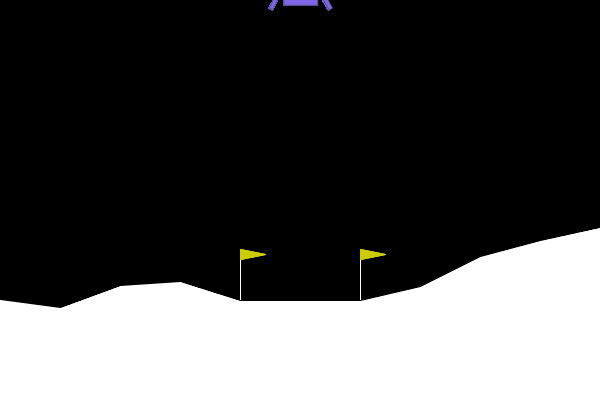

In [10]:
# This uses the function we defined in the previous step
print("🎬 Recording the updated landing...")
record_and_display_video("LunarLander-v3", model, out_file="final_victory.gif")